### Salary prediction, episode II: make it actually work (4 points)

Your main task is to use some of the tricks you've learned on the network and analyze if you can improve __validation MAE__. Try __at least 3 options__ from the list below for a passing grade. Write a short report about what you have tried. More ideas = more bonus points. 

__Please be serious:__ " plot learning curves in MAE/epoch, compare models based on optimal performance, test one change at a time. You know the drill :)

You can use either __pytorch__ or __tensorflow__ or any other framework (e.g. pure __keras__). Feel free to adapt the seminar code for your needs. For tensorflow version, consider `seminar_tf2.ipynb` as a starting point.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [49]:
data = pd.read_csv("./Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [50]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


<Axes: >

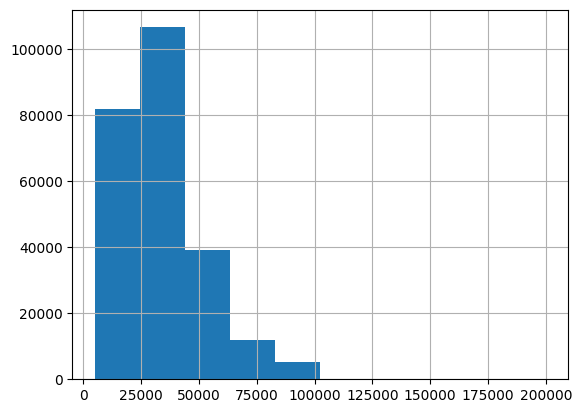

In [51]:
data.SalaryNormalized.hist()

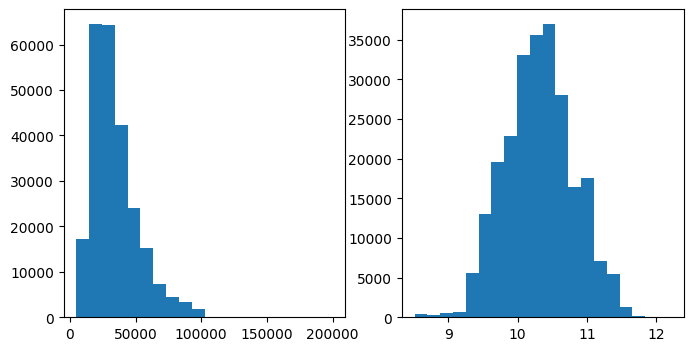

In [52]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(data["SalaryNormalized"], bins=20);

plt.subplot(1, 2, 2)
plt.hist(data['Log1pSalary'], bins=20);

In [53]:
import nltk
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

tokenizer = nltk.tokenize.WordPunctTokenizer()

data['FullDescription'] = data['FullDescription'].apply(
    lambda x: ' '.join(tokenizer.tokenize(x.lower())))

data['Title'] = data['Title'].apply(
    lambda x: ' '.join(tokenizer.tokenize(str(x).lower())))

In [54]:
from sklearn.model_selection import train_test_split
data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [55]:
from collections import Counter
token_counts = Counter() #частоты всех слов
for _, row in data_train.iterrows():
    token_counts.update(Counter(row["FullDescription"].split()))
    token_counts.update(Counter(row["Title"].split()))
    
min_count = 10

In [56]:
tokens = sorted(t for t, c in token_counts.items() if c >= min_count)

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

token_to_id = {token: idx for idx, token in enumerate(tokens)}

UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

In [57]:
def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))
        
    max_len = min(max(map(len, sequences)), max_len or float('inf'))
    
    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix
    
    return matrix

In [58]:
from sklearn.feature_extraction import DictVectorizer
top_companies, top_counts = zip(*Counter(data_train['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

In [59]:
BATCH_SIZE = 512
EPOCHS = 15

In [60]:
def model_num_params(model):
    sum_params = 0
    for param in model.named_parameters():
        num_params = np.prod(param[1].shape)
        print('{: <19} ~  {: <7} params'.format(param[0], num_params))
        sum_params += num_params
    print(f'\nIn total: {sum_params} params')
    return sum_params

In [61]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))
    
    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)
    
    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values
    
    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])


make_batch(data_train[:3], max_len=10)

{'Title': tensor([[24819, 26849, 30286,     1,     1,     1,     1],
         [26256,   178, 17212, 17987, 13981, 20789,  3625],
         [ 9523, 27317, 15930,    30,  7802, 26179,    58]]),
 'FullDescription': tensor([[24819, 26849, 30286, 29617,   859, 24819, 26849, 30286, 14791, 29617],
         [26256,   178, 17212, 17987, 13981, 20789,  3625, 22887,   792,    74],
         [27623, 19706, 18493,  5736, 14791,  7327, 24684,   859, 27317, 15930]]),
 'Categorical': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 'Log1pSalary': tensor([ 9.7115, 10.4631, 10.7144])}

In [62]:
def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch
        
        if not cycle: break

def print_metrics(model, data, batch_size=BATCH_SIZE, name="", **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    print("%s results:" % (name or ""))
    print("Mean square error: %.5f" % mse)
    print("Mean absolute error: %.5f" % mae)
    return mse, mae

In [63]:
def plot_loss_curve(train_history, val_history, title):
    plt.figure()

    plt.title('Learning curve for ' + title)

    plt.plot(train_history, label='train_loss', zorder=1)
    plt.plot(val_history, label='val_mse', zorder=1)

    plt.xlabel('Epoches')
    plt.ylabel(title)
    
    plt.legend(loc='best')
    plt.grid()

    plt.show()

In [64]:
def plot_mae_curve(train_history, val_history, title):
    plt.figure()

    plt.title('Learning curve for ' + title)

    plt.plot(train_history, label='train', zorder=1)
    plt.plot(val_history, label='val', zorder=1)

    plt.xlabel('Epoches')
    plt.ylabel(title)
    
    plt.legend(loc='best')
    plt.grid()

    plt.show()

In [65]:
from statistics import mean
from tqdm.auto import tqdm

def train_test_loop(model, criterion, optimizer, data_train=data_train,
                    batch_size=BATCH_SIZE, device=device, epochs = EPOCHS):
    mse_val = []
    loss_train = []
    mae_val = []
    mae_train = []
    for epoch in range(epochs):
        loss_t = []
        mae_t = []
        print(f"epoch: {epoch}")
        model.train()
        for i, batch in tqdm(enumerate(
                iterate_minibatches(data_train, batch_size=batch_size, device=device)),
                total=len(data_train) // batch_size
            ):
            pred = model(batch)
            loss = criterion(pred, batch[TARGET_COLUMN])
            loss_t.append(float(loss.detach().cpu().numpy()) / batch_size)  
            mae_t.append(float(torch.sum(torch.abs(pred - batch[TARGET_COLUMN])).detach().cpu().numpy()) 
                        / batch_size)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        loss_train.append(mean(loss_t))
        mae_train.append(mean(mae_t))
        mse_v, mae_v = print_metrics(model, data_val, device=device)
        mae_val.append(mae_v)
        mse_val.append(mse_v)
        
    plot_loss_curve(loss_train, mse_val, 'loss(mse) at epochs')
    plot_mae_curve(mae_train, mae_val, 'mae at epochs')

In [68]:
class SalaryPredictorCnn(torch.nn.Module):
    
    class TitleEncoder(torch.nn.Module):
        """
        data -> embeddings -> conv -> global_max_pool
        """
        def __init__(self, num_embeddings, embedding_dim=64, hid_size=64, prob=0.4):
            super().__init__()
            self.emb = torch.nn.Embedding(num_embeddings, embedding_dim)
            self.conv1 = torch.nn.Conv1d(embedding_dim, hid_size, 2)
            self.conv2 = torch.nn.Conv1d(embedding_dim, hid_size, 3)
            self.conv3 = torch.nn.Conv1d(embedding_dim, hid_size, 4)
            self.drop = torch.nn.Dropout(prob)

        def forward(self, batch):
            batch = self.emb(batch).to(device)
            batch = batch.permute((0, 2, 1)).to(device)
            batch1 = self.conv1(batch).max(dim=-1).values
            batch2 = self.conv2(batch).max(dim=-1).values
            batch3 = self.conv3(batch).max(dim=-1).values
            batch1 = self.drop(batch1)
            batch2 = self.drop(batch2)
            batch3 = self.drop(batch3)
            batches = torch.cat([batch1, batch2, batch3], axis=1)
            return batches
    
    class DescriptionEncoder(TitleEncoder):
        pass

    class CategorialEncoder(torch.nn.Module):
        def __init__(self, n_cat_features, hid_size = 64):
            super().__init__()
            self.dense1 = torch.nn.Linear(n_cat_features,  2 * hid_size)
            self.relu = torch.nn.ReLU()
            self.batch_norm = torch.nn.BatchNorm1d(2 * hid_size)
            self.dropout = torch.nn.Dropout(0.2)
            self.dense2 = torch.nn.Linear(2 * hid_size,  hid_size)

        def forward(self, batch):
            batch = self.dense1(batch)  
            batch = self.batch_norm(batch)         
            batch = self.relu(batch)
            batch = self.dropout(batch)
            return self.dense2(batch)

    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.title_encoder = self.TitleEncoder(n_tokens,64, hid_size).to(device)
        self.description_encoder = self.DescriptionEncoder(n_tokens,64, hid_size).to(device)
        self.categorial_encoder = self.CategorialEncoder(n_cat_features, hid_size).to(device)
        self.batch_norm1 = torch.nn.BatchNorm1d(hid_size * 3).to(device)
        self.dense1 = torch.nn.Linear(hid_size * 7, hid_size).to(device)
        self.relu = torch.nn.ReLU().to(device)
        self.dense2 = torch.nn.Linear(hid_size, 1).to(device)
        self.dropout1 = torch.nn.Dropout(0.4).to(device)
        
    def forward(self, batch):
        title_h = self.title_encoder(batch['Title'])
        title_h = self.batch_norm1(title_h)
        title_h = self.relu(title_h)
        
        description_h = self.description_encoder(batch['FullDescription'])
        description_h = self.batch_norm1(description_h)
        description_h = self.relu(description_h)
        
        categorial_h = self.categorial_encoder(batch['Categorical'])
        categorial_h = self.relu(categorial_h)
        
        concat = torch.cat([title_h, description_h, categorial_h], axis=1)
        concat = self.dropout1(concat)
        
        concat = self.dense1(concat)
        concat = self.relu(concat)
        return self.dense2(concat).squeeze(dim=1)


### A short report

Please tell us what you did and how did it work.

`<YOUR_TEXT_HERE>`, i guess...

## Recommended options

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...


#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

#### C) Fun with words

It's not always a good idea to train embeddings from scratch. Here's a few tricks:

* Use a pre-trained embeddings from `gensim.downloader.load`. See last lecture.
* Start with pre-trained embeddings, then fine-tune them with gradient descent. You may or may not download pre-trained embeddings from [here](http://nlp.stanford.edu/data/glove.6B.zip) and follow this [manual](https://keras.io/examples/nlp/pretrained_word_embeddings/) to initialize your Keras embedding layer with downloaded weights.
* Use the same embedding matrix in title and desc vectorizer


#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left 
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description


#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea
  
Good luck! And may the force be with you!